# B-24001B — AutoML

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from clearml import Task
import os

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.loading import load_equipment_data
from transpetro_modelos.data.preprocessing import run_preprocessing

In [2]:
# ==============================
# Configuracao
# ==============================
TASK_ID = 'c29a9de3b33b4dc1b0770907e1a6e895'  # obrigatorio
EQUIPMENT_ID = 'B-24001B_interpolated'
USE_FULL_SCORES = True

# Eventos
EVENT_DATE_F1 = '2025-01-06'
EVENT_LABEL_F1 = 'Inicio restricao (06/Jan/2025)'
EVENT_TS_F1 = pd.Timestamp(EVENT_DATE_F1)
EVENT_DATE_F2 = '2025-01-07'

PREFAILURE_DAYS=7 
NORMAL_END_DAYS=20

KEY_SENSORS=['PRESSÃO NA DESCARGA DA BOMBA', 'PRESSÃO NA SUCÇÃO DA BOMBA ',
       'TEMPERATURA DO MANCAL BOMBA LA', 'TEMPERATURA DO MANCAL BOMBA LNA',
       'TEMPERATURA DO MANCAL MOTOR LA', 'TEMPERATURA DO MANCAL MOTOR LNA',
       'VIBRAÇÃO DO MANCAL BOMBA LNA ',
       'VIBRAÇÃO DO MANCAL MOTOR LA (003)',
       'VIBRAÇÃO DO MANCAL MOTOR LA (004)',
       'VIBRAÇÃO DO MANCAL MOTOR LNA (005)',
       'VIBRAÇÃO DO MANCAL MOTOR LNA (006)']

SAVE_PLOTS=False; OUTPUT_DPI=200; OUTPUT_DIR=str(PROJECT_ROOT/'notebooks'/'b24001b'/'plots_full')

# Sensibilidade
AUTO_USE_CALIBRATED_SENSITIVITY = True
SENSITIVITY_PRESET = 'conservative'  # 'conservative' | 'balanced' | 'sensitive' | 'custom'
CALIB_START = '2024-11-10'
CALIB_END = '2024-12-20'
CALIB_PERCENTILES = [95, 97, 98, 99, 99.5, 99.7, 99.9]
CALIB_PERSISTENCE_GRID = [(1, 1), (2, 3), (3, 5), (4, 6)]
TARGET_ALERTS_PER_DAY = 2.0

# Visualizacao
PLOT_MODE = 'separated'  # 'separated' | 'consolidated'
ANOMALY_HIGHLIGHT_STYLE = 'lollipop'  # 'lollipop' | 'big_points'
SAVE_PLOTS = False
OUTPUT_DPI = 180
FIGSIZE_WIDTH = 12
PANEL_HEIGHT = 2.5

In [3]:
def load_scores(task_id):
    task = Task.get_task(task_id=task_id)
    s = task.artifacts['best_scores'].get()
    s.index = pd.to_datetime(s.index); s = s.sort_index()
    s['is_anomaly'] = s['is_anomaly'].astype(bool)
    res = task.artifacts['automl_ranking'].get() if 'automl_ranking' in task.artifacts else None
    bt = task.artifacts['best_trial'].get() if 'best_trial' in task.artifacts else None
    return s[['reconstruction_error','is_anomaly']], res, bt, task

def persistence_filter(flags, k, n):
    if k==1 and n==1: return flags.astype(bool)
    return (flags.astype(int).rolling(window=n, min_periods=n).sum() >= k).fillna(False).astype(bool)

def load_plot_base(equipment_id: str):
    config = EQUIPMENT_CONFIGS[equipment_id]
    df_raw = load_equipment_data(equipment_id, from_clearml=False)

    # Pre-split para alinhar timestamps da serie de sensores ao score
    pre_steps = config.pre_split_steps

    if pre_steps:
        df_base, _, _ = run_preprocessing(df_raw, pre_steps, fitted_scaler=None)
    else:
        df_base = df_raw

    df_base = df_base.sort_index()
    df_base.index = pd.to_datetime(df_base.index)
    return df_base, config

def model_info_str(bt):
    return (f"Modelo AutoML: {str(bt.get('model')).upper()} / {bt.get('preset')} / p{bt.get('threshold_percentile')} / "
            f"debounce {bt.get('debounce_consecutive')}  ·  pré-falha {bt.get('prefailure_alert_rate',0):.0%} @ FP {bt.get('normal_alert_rate',0):.1%}")

def _slug(t): return ''.join(c if c.isalnum() else '_' for c in str(t)).strip('_').lower()

def plot_separated(df_window, scores_window, sensors, threshold, k, n, event_ts, event_label,
                   prefailure_days, title_prefix, tag, threshold_label='Limiar', model_info='',
                   shade=True, save=False, outdir=None, dpi=200):
    plt.style.use('seaborn-v0_8-whitegrid')
    flags = persistence_filter(scores_window['reconstruction_error'] > threshold, k=k, n=n)
    anom_idx = scores_window.index[flags]
    if save and outdir:
        from pathlib import Path as _P; _P(outdir).mkdir(parents=True, exist_ok=True)
    saved=[]
    panels = list(sensors) + ['__score__']
    for col in panels:
        fig, ax = plt.subplots(figsize=(14,3.2))
        if col == '__score__':
            y=scores_window['reconstruction_error']
            ax.plot(y.index,y,color='purple',lw=0.9,alpha=0.6,label='Score de Anomalia')
            ax.axhline(threshold,color='red',ls='--',lw=1.2,label=threshold_label)
            if len(anom_idx): ax.scatter(anom_idx,y.reindex(anom_idx),s=28,color='red',zorder=4,label='Alerta')
            ax.set_ylabel('Score'); ttl='Score de Anomalia'
        else:
            if col not in df_window.columns: plt.close(fig); continue
            ax.plot(df_window.index, df_window[col], color='steelblue', lw=1.0, alpha=0.85, label=col)
            av = df_window[col].reindex(anom_idx).dropna()
            if not av.empty: ax.scatter(av.index, av.values, s=28, color='red', zorder=4, label='Anomalia')
            ax.set_ylabel(col, fontsize=9); ttl=col
        if shade: ax.axvspan(event_ts-pd.Timedelta(days=prefailure_days), event_ts, color='orange', alpha=0.08)
        ax.axvline(event_ts, color='orange', ls='--', lw=1.4, label=event_label)
        ax.set_xlabel('Tempo'); ax.legend(loc='upper left', fontsize=8)
        ax.set_title(f'{title_prefix} | {ttl}', fontsize=12, fontweight='bold')
        if model_info: ax.text(0.5,1.10, model_info, transform=ax.transAxes, ha='center', va='bottom', fontsize=8, color='dimgray')
        fig.tight_layout()
        if save and outdir: p=f'{outdir}/{tag}_{_slug(ttl)}.png'; fig.savefig(p,dpi=dpi,bbox_inches='tight'); saved.append(p)
        plt.show()
    return saved

In [4]:
scores, automl_results, best_trial, task = load_scores(TASK_ID)
df_base, cfg = load_plot_base(EQUIPMENT_ID)
MODEL_INFO = model_info_str(best_trial)
print('Task:', task.name, '| trials:', len(automl_results))
print(MODEL_INFO)

Task: automl_B-24001B_interpolated_full | trials: 4968
Modelo AutoML: DENSE / baseline_interpolated / p90.0 / debounce 1  ·  pré-falha 100% @ FP 0.0%


In [5]:
cols=[x for x in ['model','preset','threshold_percentile','debounce_consecutive','prefailure_alert_rate','normal_alert_rate','composite_score'] if x in automl_results.columns]
fmt={'prefailure_alert_rate':'{:.2%}','normal_alert_rate':'{:.2%}','composite_score':'{:.4f}','threshold_percentile':'{:.1f}'}
display(automl_results[cols].head(10).style.format(fmt).background_gradient(subset=['prefailure_alert_rate'],cmap='Greens').background_gradient(subset=['normal_alert_rate'],cmap='Reds_r'))

,model,preset,threshold_percentile,debounce_consecutive,prefailure_alert_rate,normal_alert_rate,composite_score
0,dense,baseline_interpolated,90.0,1,100.00%,0.00%,1.0000
1,dense,baseline_interpolated,90.0,1,100.00%,0.00%,1.0000
2,dense,baseline_interpolated,90.0,1,100.00%,0.00%,1.0000
3,dense,baseline_interpolated,90.0,1,100.00%,0.00%,1.0000
4,dense,baseline_interpolated,90.0,1,100.00%,0.00%,1.0000
5,dense,baseline_interpolated,90.0,1,100.00%,0.00%,1.0000
6,dense,baseline_interpolated,90.0,1,100.00%,0.00%,1.0000
7,dense,baseline_interpolated,90.0,1,100.00%,0.00%,1.0000
8,dense,baseline_interpolated,90.0,1,100.00%,0.00%,1.0000
9,dense,baseline_interpolated,90.0,1,100.00%,0.00%,1.0000


In [6]:
def calculate_metrics(scores, threshold, k, n, event_ts, prefailure_days, normal_end_days):
    """
    Calcula métricas para uma combinação de threshold + debounce
    """
    # Extrair reconstruction error
    _e = scores['reconstruction_error']
    
    # Definir períodos
    _ne = event_ts - pd.Timedelta(days=normal_end_days)
    _ps = event_ts - pd.Timedelta(days=prefailure_days)
    
    _mn = scores.index < _ne                                           # Normal
    _mp = (scores.index >= _ps) & (scores.index < event_ts)           # Pré-falha
    _mpost = scores.index >= event_ts                                 # Pós-falha
    _early = (scores.index >= event_ts - pd.Timedelta(days=14)) & (scores.index < _ps)  # Early
    
    # Aplicar threshold + debounce
    flags = persistence_filter(_e > threshold, k, n)
    
    # Calcular métricas
    prefailure_rate = flags[_mp].mean() if _mp.sum() > 0 else 0
    normal_rate = flags[_mn].mean() if _mn.sum() > 0 else 0
    early_count = int(flags[_early].sum())
    post_count = int(flags[_mpost].sum())
    prefailure_count = int(flags[_mp].sum())
    normal_count = int(flags[_mn].sum())
    
    return {
        'threshold': threshold,
        'k': k,
        'n': n,
        'prefailure_rate': prefailure_rate,
        'prefailure_count': prefailure_count,
        'normal_rate': normal_rate,
        'normal_count': normal_count,
        'early_count': early_count,
        'post_count': post_count,
        'flags': flags
    }

_e = scores['reconstruction_error']
_ne = EVENT_TS_F1 - pd.Timedelta(days=NORMAL_END_DAYS)
_ps = EVENT_TS_F1 - pd.Timedelta(days=PREFAILURE_DAYS)
_mn = scores.index < _ne

# Estatísticas do período normal (usadas para média + y*std)
mu_normal = float(_e[_mn].mean())
std_normal = float(_e[_mn].std())

print(f"Média (normal): {mu_normal:.6f}")
print(f"Desvio padrão (normal): {std_normal:.6f}\n")

# Testar diferentes valores de y
print("Explorando diferentes valores de y (threshold = média + y·std):\n")

y_values = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
results_y = []

for y in y_values:
    thr = mu_normal + y * std_normal
    m = calculate_metrics(scores, thr, 1, 1, EVENT_TS_F1, PREFAILURE_DAYS, NORMAL_END_DAYS)
    m['y'] = y
    results_y.append(m)
    print(f"  y={y:4.1f}  →  Pré-falha: {m['prefailure_rate']:6.1%} | Normal: {m['normal_rate']:6.2%} | Threshold: {thr:.6f}")

df_y = pd.DataFrame(results_y)
print(f"\n✓ {len(df_y)} valores de y testados")

# Grid Search: y × debounce, priorizando redução de FP
print("\nGrid Search (média + y·std): Priorizar Redução de FP\n")

y_values = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
debounces = [(1,1), (2,3), (3,5), (5,7), (10,12), (12,15), (15,20)]

results_std = []

for y in y_values:
    thr = mu_normal + y * std_normal
    for k, n in debounces:
        m = calculate_metrics(scores, thr, k, n, EVENT_TS_F1, PREFAILURE_DAYS, NORMAL_END_DAYS)
        m['y'] = y

        score = -m['normal_rate'] * 10 + m['prefailure_rate'] * 1
        m['score'] = score
        m['priority'] = 'FP'

        results_std.append(m)

df_results_std = pd.DataFrame(results_std)
df_sorted_std = df_results_std.sort_values('score', ascending=False)

print(f"✓ {len(df_results_std)} combinações testadas\n")
print(f"Score = -FP×10 + Pré-falha×1")
print(f"(Prioriza FP baixo, mantém pré-falha)\n")

Média (normal): 0.535750
Desvio padrão (normal): 0.600091

Explorando diferentes valores de y (threshold = média + y·std):

  y= 1.5  →  Pré-falha:   5.6% | Normal:  4.85% | Threshold: 1.435887
  y= 2.0  →  Pré-falha:   4.4% | Normal:  4.63% | Threshold: 1.735933
  y= 2.5  →  Pré-falha:   3.8% | Normal:  4.21% | Threshold: 2.035978
  y= 3.0  →  Pré-falha:   3.5% | Normal:  3.62% | Threshold: 2.336024
  y= 3.5  →  Pré-falha:   3.5% | Normal:  2.46% | Threshold: 2.636069
  y= 4.0  →  Pré-falha:   3.2% | Normal:  1.21% | Threshold: 2.936115
  y= 4.5  →  Pré-falha:   3.2% | Normal:  0.66% | Threshold: 3.236160
  y= 5.0  →  Pré-falha:   2.9% | Normal:  0.38% | Threshold: 3.536206

✓ 8 valores de y testados

Grid Search (média + y·std): Priorizar Redução de FP

✓ 56 combinações testadas

Score = -FP×10 + Pré-falha×1
(Prioriza FP baixo, mantém pré-falha)



In [7]:
print("="*80)
print(" TOP 10: PRIORIZAR REDUÇÃO DE FP (média + y·std)")
print("="*80 + "\n")

top_10_std = df_sorted_std.head(10)

best_row_std = df_sorted_std.iloc[0]
CURRENT_Y = best_row_std['y']
CURRENT_K_STD = int(best_row_std['k'])
CURRENT_N_STD = int(best_row_std['n'])

print(f"Melhor encontrada: y={CURRENT_Y} + k={CURRENT_K_STD}/n={CURRENT_N_STD}\n")

for i, (idx, row) in enumerate(top_10_std.iterrows(), 1):
    marker = " ← MELHOR" if (row['y'] == CURRENT_Y and
                              row['k'] == CURRENT_K_STD and row['n'] == CURRENT_N_STD) else ""
    print(f"{i:2d}. y={row['y']:4.1f} | k={row['k']:2.0f}/n={row['n']:2.0f}  →  "
          f"FP: {row['normal_rate']:5.2%} | Pré: {row['prefailure_rate']:6.1%} | "
          f"Early: {row['early_count']:3.0f} | Score: {row['score']:7.3f}{marker}")

print("\n" + "="*80)
print("\nScore = -FP×10 + Pré-falha×1")
print("Quanto MAIOR o score, MELHOR (menos FP)\n")

 TOP 10: PRIORIZAR REDUÇÃO DE FP (média + y·std)

Melhor encontrada: y=5.0 + k=10/n=12

 1. y= 5.0 | k=10/n=12  →  FP: 0.00% | Pré:   0.0% | Early:  16 | Score:   0.000 ← MELHOR
 2. y= 5.0 | k=12/n=15  →  FP: 0.00% | Pré:   0.0% | Early:  15 | Score:   0.000
 3. y= 5.0 | k=15/n=20  →  FP: 0.00% | Pré:   0.0% | Early:  14 | Score:   0.000
 4. y= 4.5 | k=12/n=15  →  FP: 0.00% | Pré:   0.0% | Early:  15 | Score:   0.000
 5. y= 4.5 | k=15/n=20  →  FP: 0.00% | Pré:   0.0% | Early:  14 | Score:   0.000
 6. y= 5.0 | k= 2/n= 3  →  FP: 0.32% | Pré:   2.6% | Early:  29 | Score:  -0.006
 7. y= 4.5 | k=10/n=12  →  FP: 0.06% | Pré:   0.0% | Early:  16 | Score:  -0.006
 8. y= 5.0 | k= 3/n= 5  →  FP: 0.30% | Pré:   2.3% | Early:  29 | Score:  -0.007
 9. y= 5.0 | k= 1/n= 1  →  FP: 0.38% | Pré:   2.9% | Early:  29 | Score:  -0.009
10. y= 5.0 | k= 5/n= 7  →  FP: 0.22% | Pré:   0.9% | Early:  25 | Score:  -0.013


Score = -FP×10 + Pré-falha×1
Quanto MAIOR o score, MELHOR (menos FP)



In [8]:
_e = scores['reconstruction_error']
_ne = EVENT_TS_F1 - pd.Timedelta(days=NORMAL_END_DAYS)
_ps = EVENT_TS_F1 - pd.Timedelta(days=PREFAILURE_DAYS)
_mn = scores.index < _ne
_mp = (scores.index >= _ps) & (scores.index < EVENT_TS_F1)
_mpost = scores.index >= EVENT_TS_F1
_early = (scores.index >= EVENT_TS_F1 - pd.Timedelta(days=14)) & (scores.index < _ps)

TUNE_Y = 8
TUNE_K, TUNE_N = 1, 1   

mu_normal = float(_e[_mn].mean())
std_normal = float(_e[_mn].std())

selected_threshold = mu_normal + TUNE_Y * std_normal
selected_k, selected_n = TUNE_K, TUNE_N
threshold_label = f'Limiar média + {TUNE_Y}·std + debounce {TUNE_K}/{TUNE_N}'
flags = persistence_filter(_e > selected_threshold, selected_k, selected_n)

print(threshold_label); print('-'*54)
print(f'PRÉ-FALHA (7d):        {flags[_mp].mean():.1%}  ({int(flags[_mp].sum())})')
print(f'FP precoce (14-7d):    {int(flags[_early].sum())} alertas')
print(f'NORMAL (<-20d):        {flags[_mn].mean():.2%}  ({int(flags[_mn].sum())})')
print(f'pós-falha (evento+reinicio): {int(flags[_mpost].sum())}')

Limiar média + 8·std + debounce 1/1
------------------------------------------------------
PRÉ-FALHA (7d):        2.6%  (9)
FP precoce (14-7d):    18 alertas
NORMAL (<-20d):        0.10%  (5)
pós-falha (evento+reinicio): 4


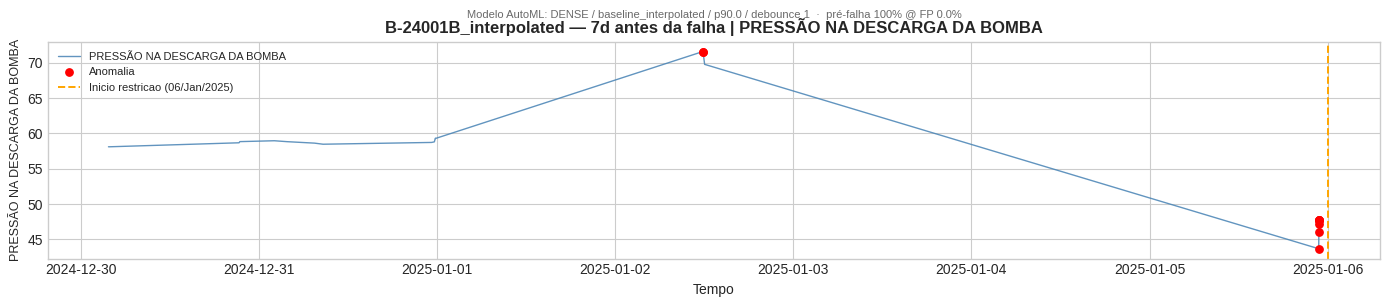

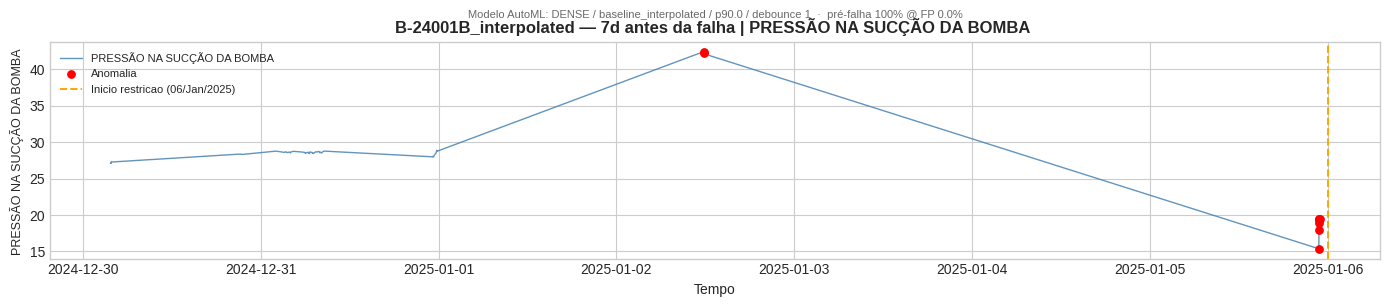

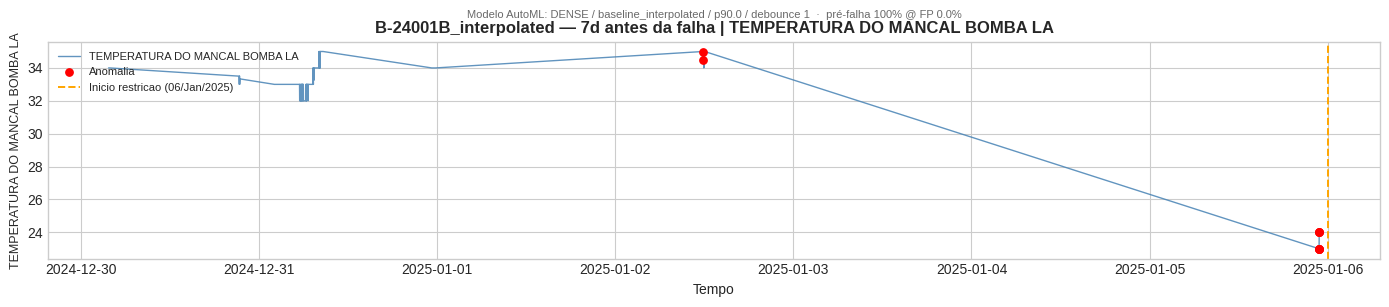

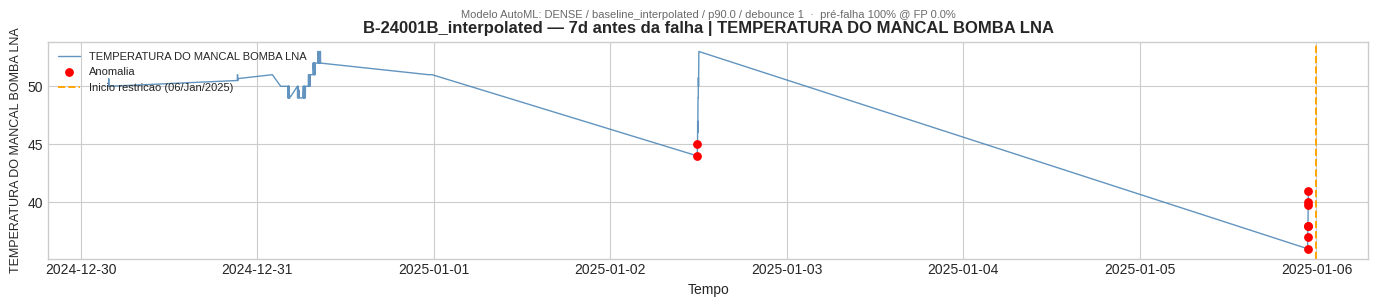

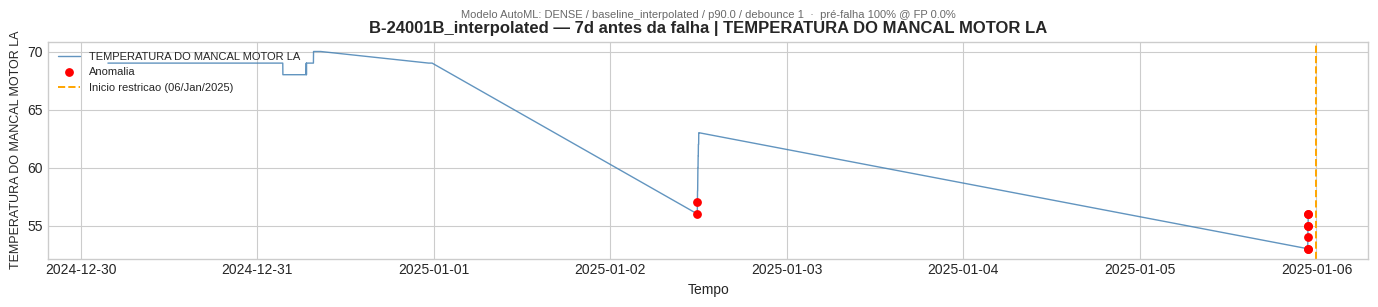

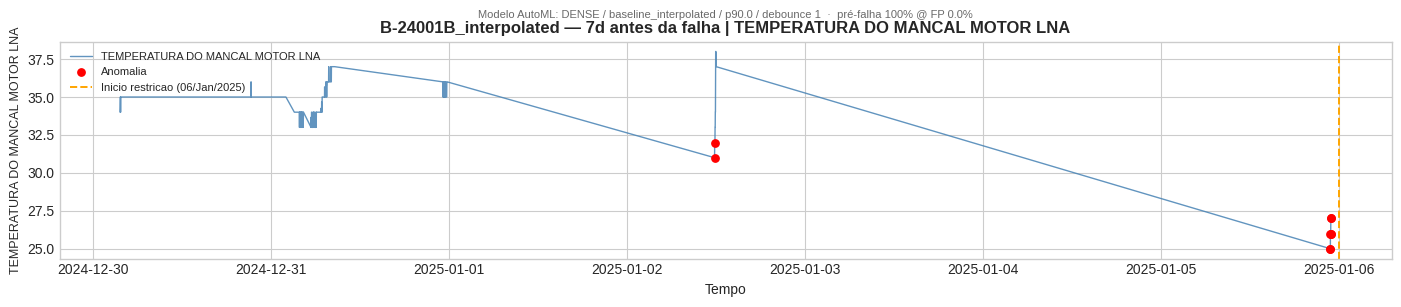

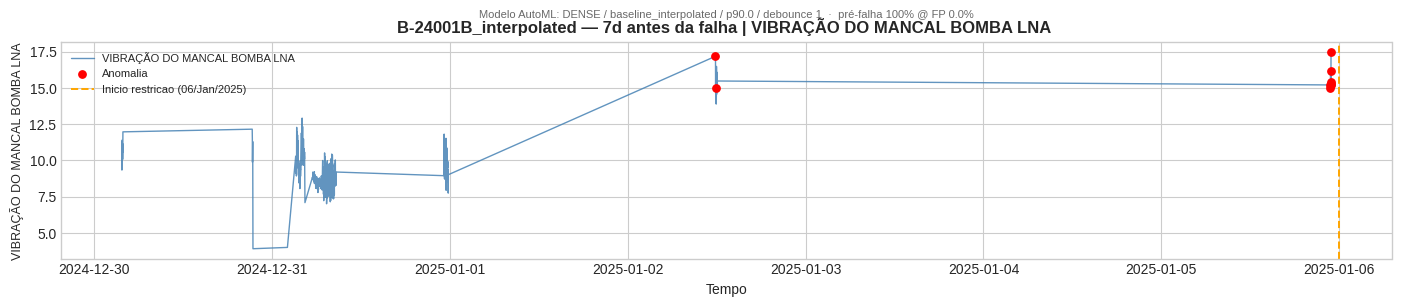

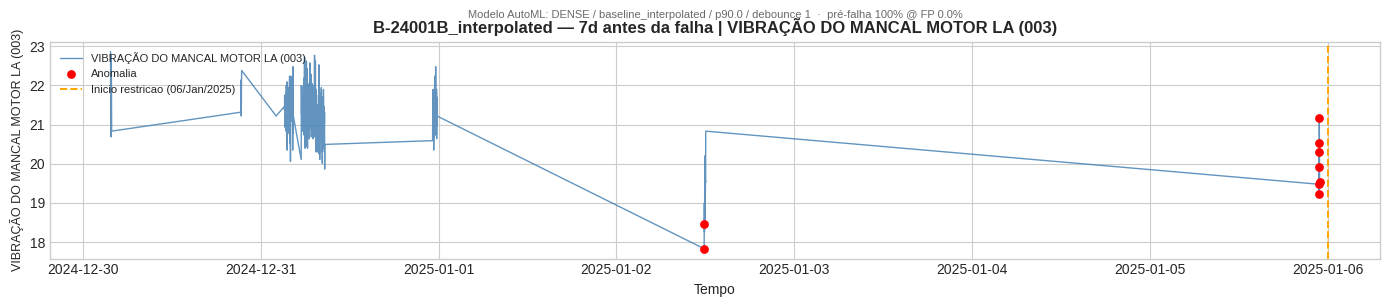

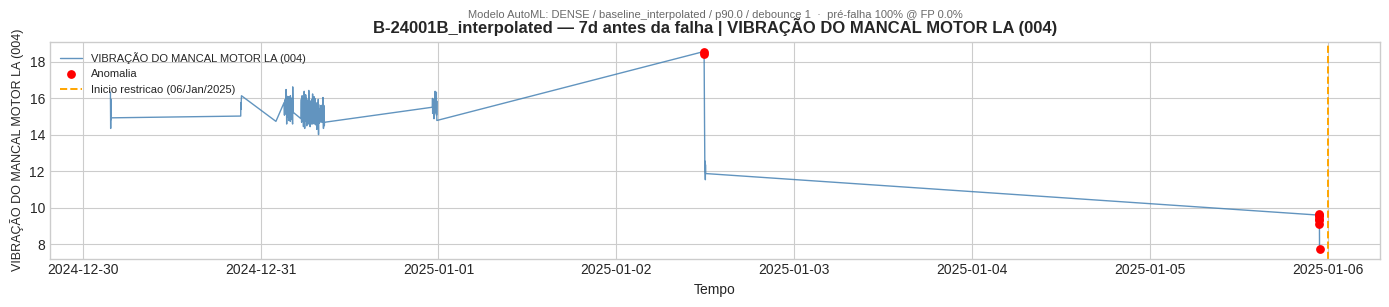

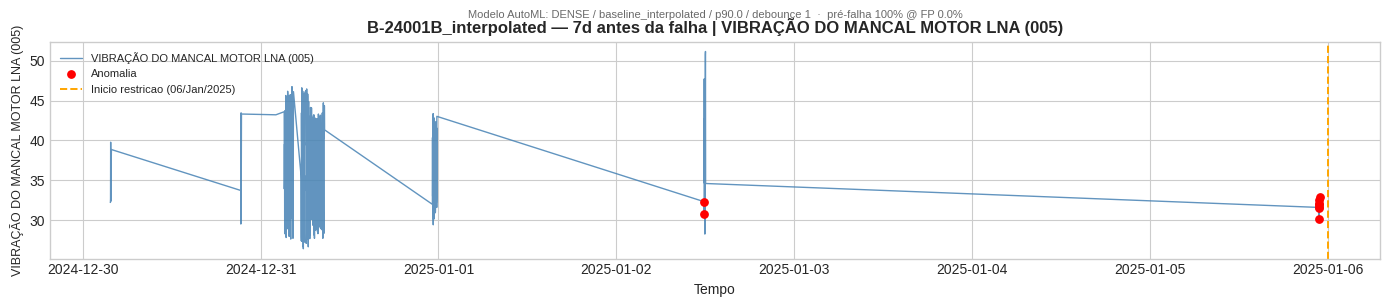

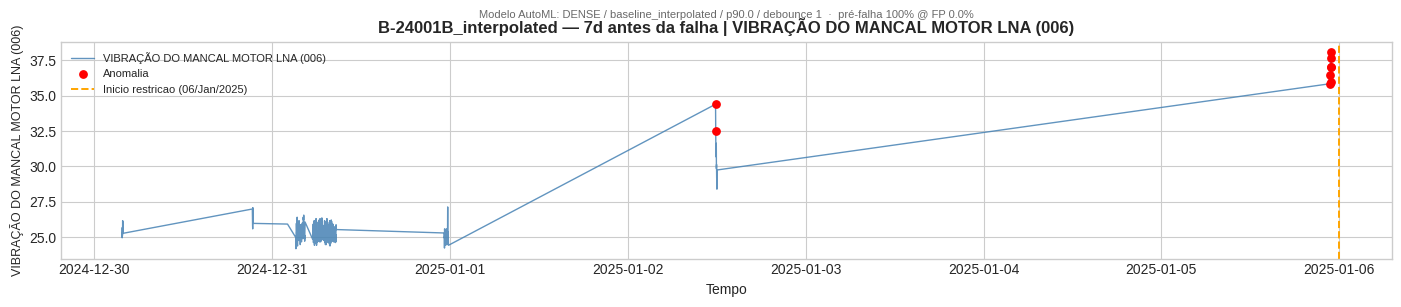

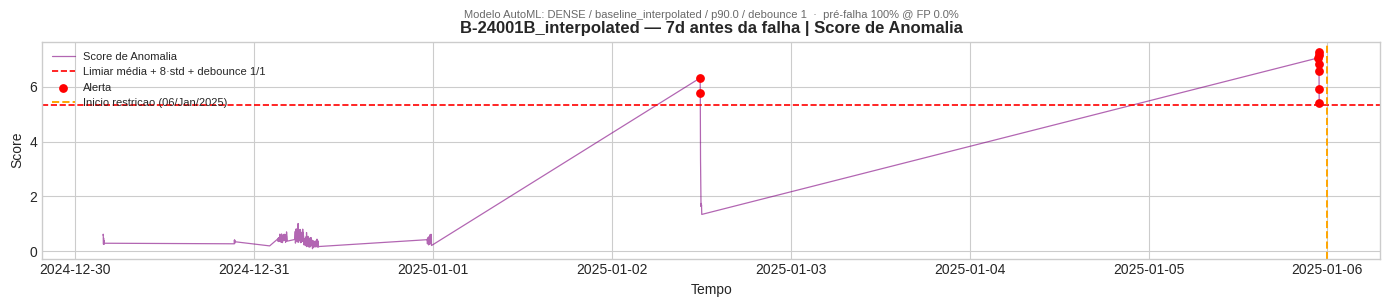

In [13]:
days = 7
z=EVENT_TS_F1-pd.Timedelta(days=days); dfw=df_base.loc[z:EVENT_TS_F1]; sw=scores.loc[z:EVENT_TS_F1]
common=dfw.index.intersection(sw.index); dfw,sw=dfw.loc[common],sw.loc[common]

sensors=[s for s in KEY_SENSORS if s in dfw.columns]

saved=plot_separated(dfw,sw,sensors,selected_threshold,selected_k,selected_n,EVENT_TS_F1,EVENT_LABEL_F1,PREFAILURE_DAYS,
   title_prefix=f'{EQUIPMENT_ID} — {days}d antes da falha',tag='full_zoom14d',threshold_label=threshold_label,
   model_info=MODEL_INFO,shade=False,save=SAVE_PLOTS,outdir=OUTPUT_DIR,dpi=OUTPUT_DPI)

o período de 31/03/24 até 17/09/24 apresentam valores 0 para todas as variáveis, exceto a variável de pressão da descarga da bomba

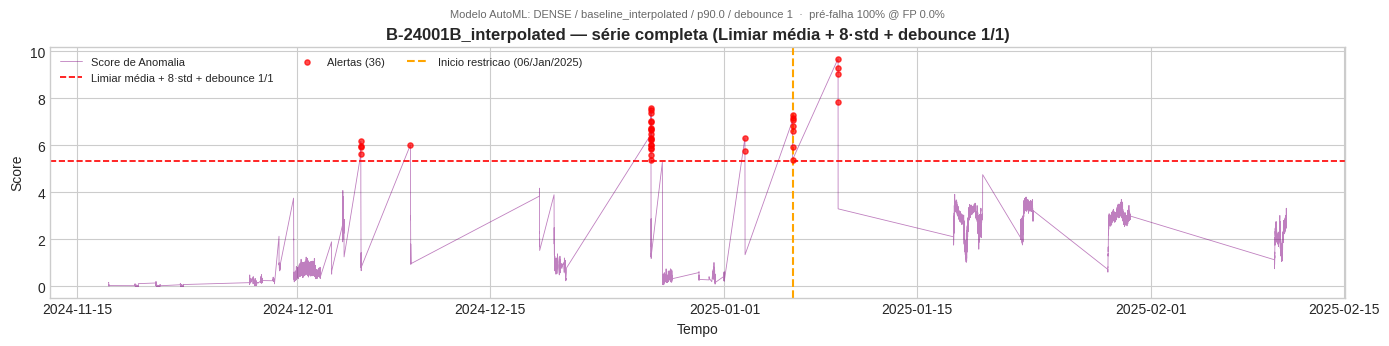

Alertas na série inteira: 36 | no começo (normal, <-20d): 5
depois do evento F2 (pós-falha): 4


In [12]:
plt.style.use('seaborn-v0_8-whitegrid'); fig,ax=plt.subplots(figsize=(14,3.6)); y=scores['reconstruction_error']

fl_all=persistence_filter(y>selected_threshold, selected_k, selected_n)
ax.plot(scores.index,y,color='purple',lw=0.6,alpha=0.5,label='Score de Anomalia')
ax.axhline(selected_threshold,color='red',ls='--',lw=1.2,label=threshold_label)

idx=scores.index[fl_all]; ax.scatter(idx,y[idx],s=14,color='red',alpha=0.7,zorder=4,label=f'Alertas ({len(idx)})')
ax.axvline(EVENT_TS_F1,color='orange',ls='--',lw=1.5,label=EVENT_LABEL_F1)
ax.set_ylabel('Score'); ax.set_xlabel('Tempo'); ax.legend(loc='upper left',fontsize=8,ncol=3)
ax.set_title(f'{EQUIPMENT_ID} — série completa ({threshold_label})',fontweight='bold')
ax.text(0.5,1.12,MODEL_INFO,transform=ax.transAxes,ha='center',fontsize=8,color='dimgray'); fig.tight_layout()

if SAVE_PLOTS: os.makedirs(OUTPUT_DIR,exist_ok=True); fig.savefig(f'{OUTPUT_DIR}/full_serie_completa.png',dpi=OUTPUT_DPI,bbox_inches='tight')
plt.show(); print(f'Alertas na série inteira: {int(fl_all.sum())} | no começo (normal, <-{NORMAL_END_DAYS}d): {int(fl_all[scores.index<EVENT_TS_F1-pd.Timedelta(days=NORMAL_END_DAYS)].sum())}')
alertas_pos_falha = int(fl_all[scores.index >= EVENT_DATE_F2].sum())
print(f'depois do evento F2 (pós-falha): {alertas_pos_falha}')